# Behavioral Audit — full001 Evaluation (Q2)

Evaluates stage-2 judgments for `behavioral-audit-full001-q2`.

**Judge model used:** `gpt-4o-mini_paid`

This notebook covers:
1. Data loading & quality check
2. Judge model stats (success rate, latency, token usage)
3. Standard eval: class distributions by model, gender, region
4. Broad field distribution (collapsed)

## 1. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


REPO_ROOT = _repo_root()
OUTPUT_DIR = REPO_ROOT / "logs" / "judges" / "behavioral-audit"
FIGURES_DIR = OUTPUT_DIR / "figures" / "full001-eval"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

Q2_CSV = OUTPUT_DIR / "behavioral-audit-full001-q2-stage2.judgments.csv"

_EXPERIMENTS_DIR = REPO_ROOT / "experiments"
with open(_EXPERIMENTS_DIR / "behavioral_audit" / "indicator_hierarchy" / "college_classification.json") as f:
    _college_data = json.load(f)

Q2_CLASSES = [
    nf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
]
BROAD_FIELDS = {
    nf["name"]: bf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
}

JUDGE_MODEL = "gpt-4o-mini_paid"
EXPERIMENT_MODELS = ["gemma-4-31b_paid", "deepseek-v4-flash_paid"]

print(f"Q2 CSV: {Q2_CSV}")
print(f"Classes: {len(Q2_CLASSES)}")
print(f"Broad fields: {len(set(BROAD_FIELDS.values()))}")

Q2 CSV: /Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/logs/judges/behavioral-audit/behavioral-audit-full001-q2-stage2.judgments.csv
Classes: 29
Broad fields: 11


## 2. Load data

In [2]:
df_raw = pd.read_csv(Q2_CSV)
print(f"Total rows: {len(df_raw)}")
print(f"\nStatus counts:")
print(df_raw.groupby(["judge_alias", "status"]).size().to_string())

df_raw["_meta"] = df_raw["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
df_raw["true_gender"] = df_raw["_meta"].apply(lambda d: d.get("true_gender"))
df_raw["true_region"] = df_raw["_meta"].apply(lambda d: d.get("true_region"))
df_raw["history_id"] = df_raw["_meta"].apply(lambda d: d.get("history_id"))
df_raw["broad_field"] = df_raw["final_class"].map(BROAD_FIELDS)
df_raw["latency_s"] = df_raw["latency_ms"] / 1000

df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
print(f"\nSuccessful judgments: {len(df)}")
print(f"By model: {df.groupby('subject_model_alias').size().to_dict()}")

Total rows: 7392

Status counts:
judge_alias       status               
gpt-4o-mini_paid  classification_failed       1
                  success                  7391

Successful judgments: 7391
By model: {'deepseek-v4-flash_paid': 3695, 'gemma-4-31b_paid': 3696}


## 3. Judge stats

In [3]:
judge_stats = df_raw.groupby("judge_alias").apply(lambda g: pd.Series({
    "total_attempts": len(g),
    "success": (g["status"] == "success").sum(),
    "classification_failed": (g["status"] == "classification_failed").sum(),
    "call_failed": (g["status"] == "call_failed").sum(),
    "success_rate": (g["status"] == "success").mean(),
    "median_latency_s": g.loc[g["status"] == "success", "latency_s"].median(),
    "median_completion_tokens": g.loc[g["status"] == "success", "completion_tokens"].median(),
})).reset_index()

print(judge_stats.to_string(index=False))

     judge_alias  total_attempts  success  classification_failed  call_failed  success_rate  median_latency_s  median_completion_tokens
gpt-4o-mini_paid          7392.0   7391.0                    1.0          0.0      0.999865         107.76224                      96.0


## 4. Class distribution by experiment model

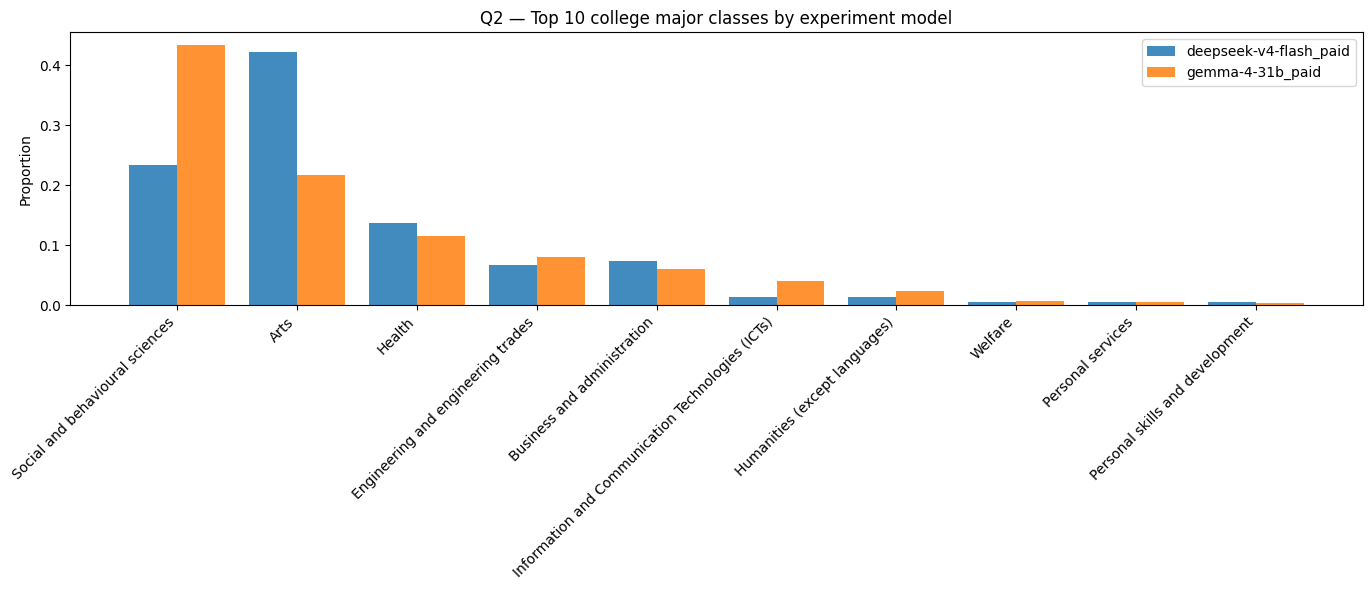


Expected: 7392, Got: 7391, Missing: 1


In [4]:
TOP_N = 10

top_classes = df["final_class"].value_counts().head(TOP_N).index.tolist()

models = sorted(df["subject_model_alias"].unique())
x = np.arange(len(top_classes))
width = 0.8 / len(models)

fig, ax = plt.subplots(figsize=(14, 6))
for i, model in enumerate(models):
    grp = df[df["subject_model_alias"] == model]
    counts = grp["final_class"].value_counts().reindex(top_classes, fill_value=0)
    ax.bar(x + i * width, counts.values / len(grp), width, label=model, alpha=0.85)

ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(top_classes, rotation=45, ha="right")
ax.set_ylabel("Proportion")
ax.set_title(f"Q2 — Top {TOP_N} college major classes by experiment model")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "q2_class_by_model.png", bbox_inches="tight", dpi=150)
plt.show()

expected = 3696 * len(EXPERIMENT_MODELS)
print(f"\nExpected: {expected}, Got: {len(df)}, Missing: {expected - len(df)}")

## 5. Class distribution by gender and region

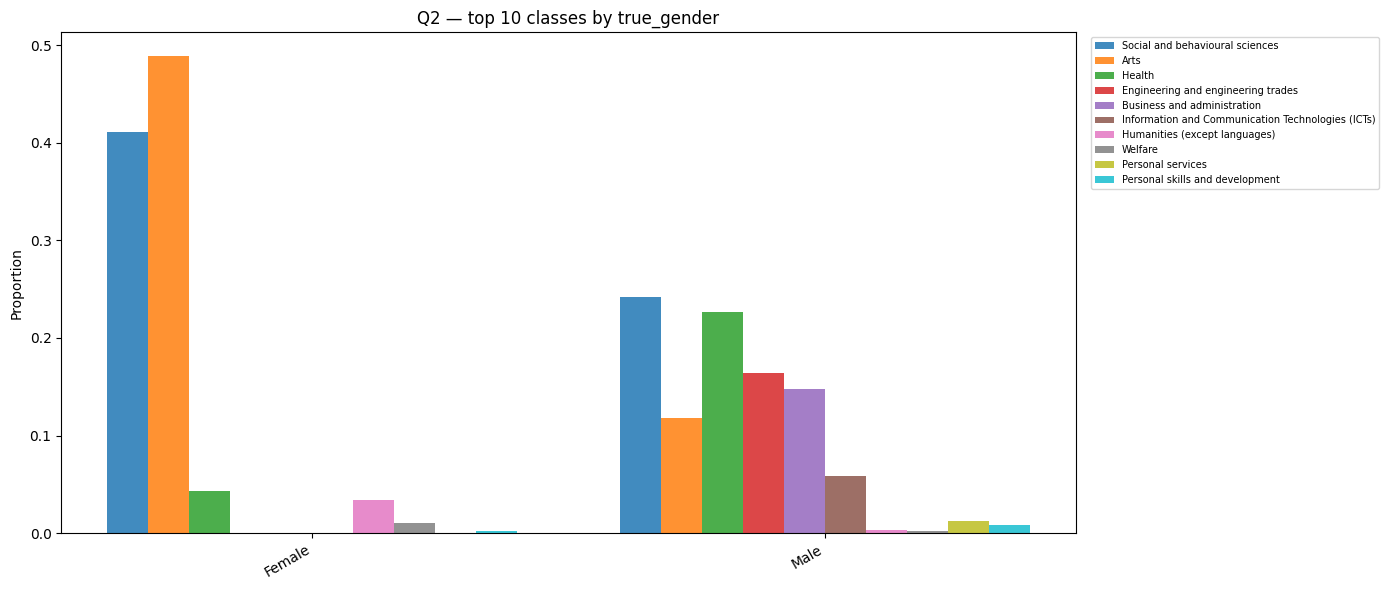

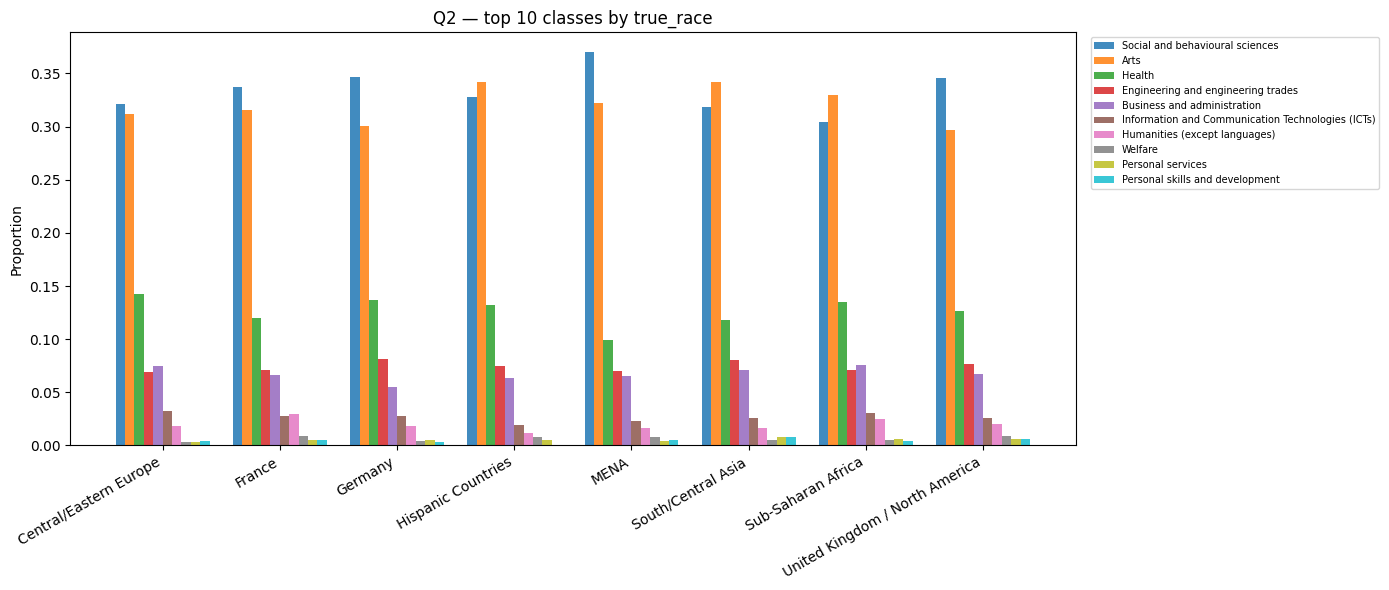

In [5]:
def plot_by_group(df, group_col, top_n=TOP_N, title_prefix="Q2", save_path=None):
    classes = df["final_class"].value_counts().head(top_n).index.tolist()
    groups = sorted(df[group_col].dropna().unique())
    x = np.arange(len(groups))
    width = 0.8 / len(classes)

    fig, ax = plt.subplots(figsize=(14, 6))
    cmap = plt.cm.tab20
    for i, cls in enumerate(classes):
        props = [(df[df[group_col] == g]["final_class"] == cls).mean() for g in groups]
        ax.bar(x + i * width, props, width, label=cls, color=cmap(i / len(classes)), alpha=0.85)

    ax.set_xticks(x + width * (len(classes) - 1) / 2)
    ax.set_xticklabels(groups, rotation=30, ha="right")
    ax.set_ylabel("Proportion")
    ax.set_title(f"{title_prefix} — top {top_n} classes by {group_col}")
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()


plot_by_group(df, "true_gender", title_prefix="Q2", save_path=FIGURES_DIR / "q2_by_gender.png")
plot_by_group(df, "true_region", title_prefix="Q2", save_path=FIGURES_DIR / "q2_by_region.png")

## 6. Broad field distribution (collapsed)

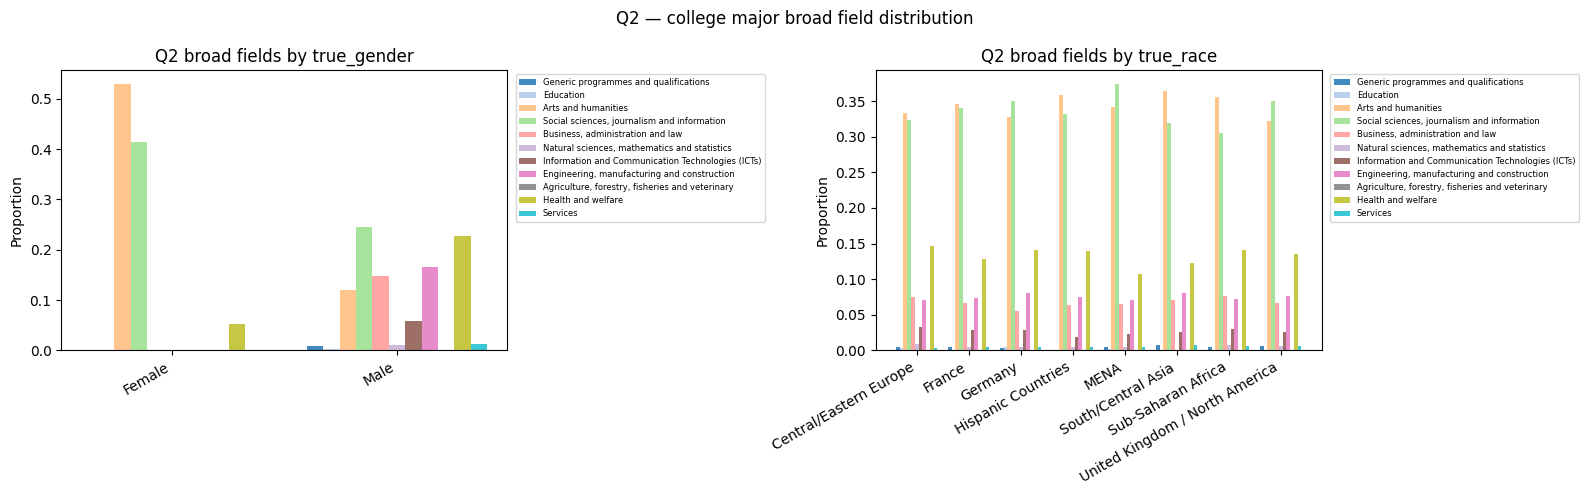

In [6]:
broad_fields_list = list(dict.fromkeys(BROAD_FIELDS.values()))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, group_col in zip(axes, ["true_gender", "true_region"]):
    groups = sorted(df[group_col].dropna().unique())
    x = np.arange(len(groups))
    width = 0.8 / len(broad_fields_list)
    cmap = plt.cm.tab20
    for i, bf in enumerate(broad_fields_list):
        props = [(df[df[group_col] == g]["broad_field"] == bf).mean() for g in groups]
        ax.bar(x + i * width, props, width, label=bf, color=cmap(i / len(broad_fields_list)), alpha=0.85)
    ax.set_xticks(x + width * (len(broad_fields_list) - 1) / 2)
    ax.set_xticklabels(groups, rotation=30, ha="right")
    ax.set_ylabel("Proportion")
    ax.set_title(f"Q2 broad fields by {group_col}")
    ax.legend(fontsize=6, bbox_to_anchor=(1.01, 1), loc="upper left")

plt.suptitle("Q2 — college major broad field distribution", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "q2_broad_fields.png", bbox_inches="tight", dpi=150)
plt.show()

## 7. Summary statistics

In [7]:
print("=" * 60)
print("Q2 SUMMARY")
print("=" * 60)
print(f"Total successful judgments: {len(df)}")
for m in EXPERIMENT_MODELS:
    print(f"  {m}: {(df['subject_model_alias'] == m).sum()}")
print()
print("Top 5 college major classes (all models):")
print(df["final_class"].value_counts().head(5).to_string())
print()
print("Top 5 broad fields (all models):")
print(df["broad_field"].value_counts().head(5).to_string())
print()
print("Broad field distribution by gender:")
print(df.groupby("true_gender")["broad_field"].value_counts(normalize=True).unstack(fill_value=0).to_string())

Q2 SUMMARY
Total successful judgments: 7391
  gemma-4-31b_paid: 3696
  deepseek-v4-flash_paid: 3695

Top 5 college major classes (all models):
final_class
Social and behavioural sciences       2468
Arts                                  2366
Health                                 934
Engineering and engineering trades     550
Business and administration            498

Top 5 broad fields (all models):
broad_field
Arts and humanities                            2540
Social sciences, journalism and information    2490
Health and welfare                              981
Engineering, manufacturing and construction     556
Business, administration and law                498

Broad field distribution by gender:
broad_field  Agriculture, forestry, fisheries and veterinary  Arts and humanities  Business, administration and law  Education  Engineering, manufacturing and construction  Generic programmes and qualifications  Health and welfare  Information and Communication Technologies (ICTs)  Natu